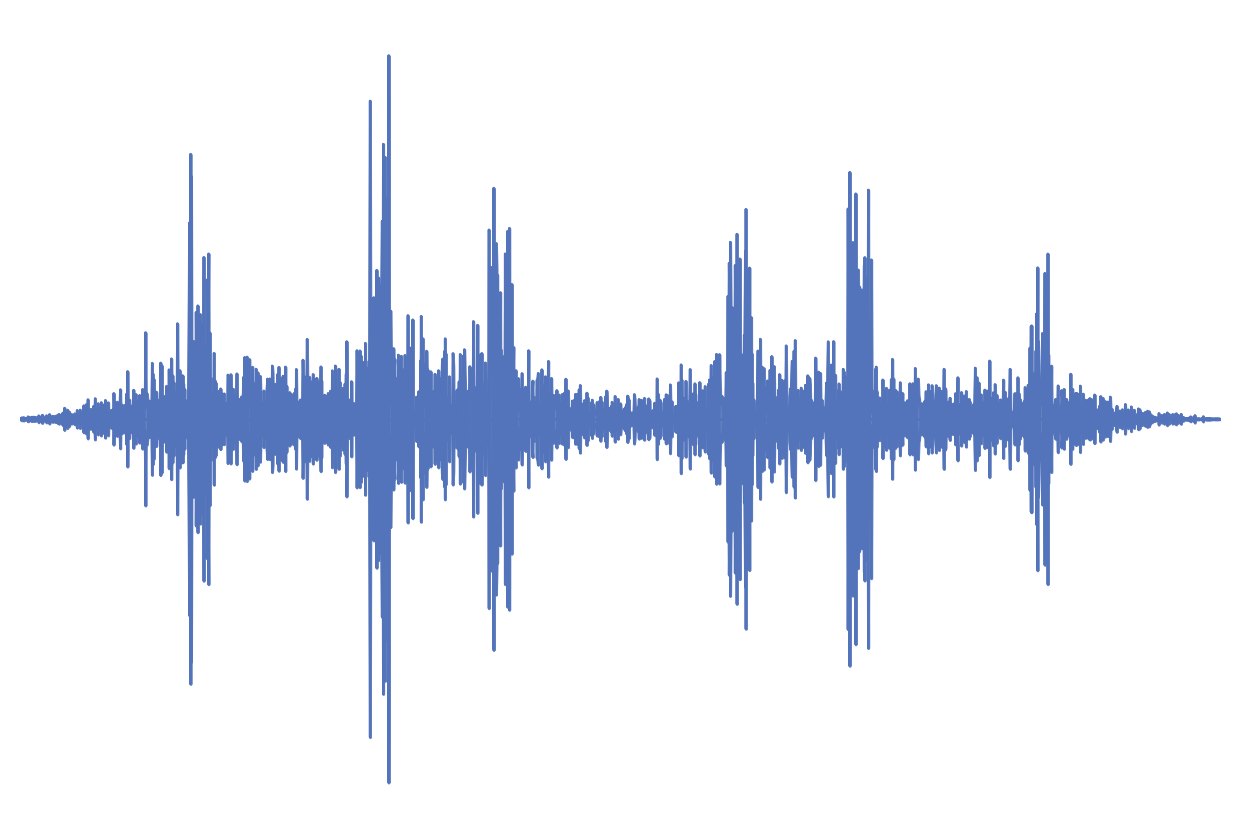

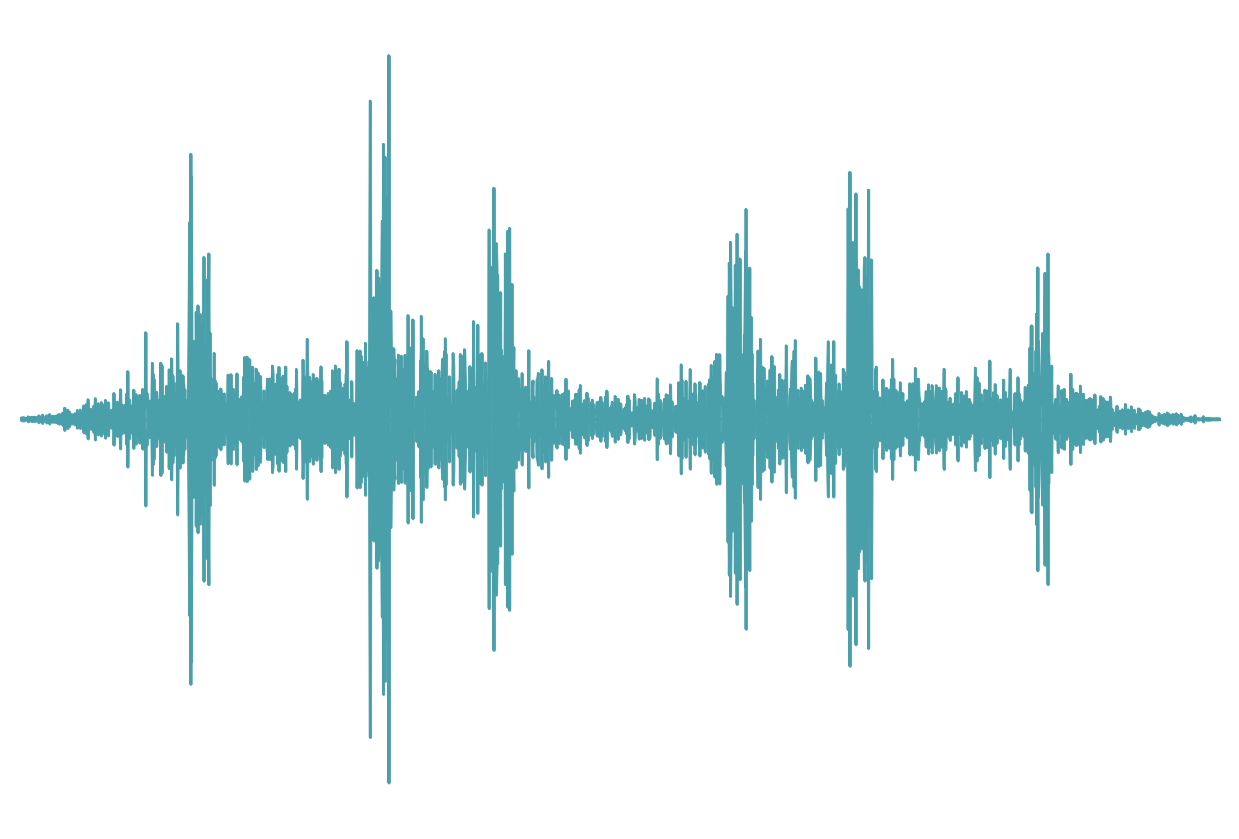

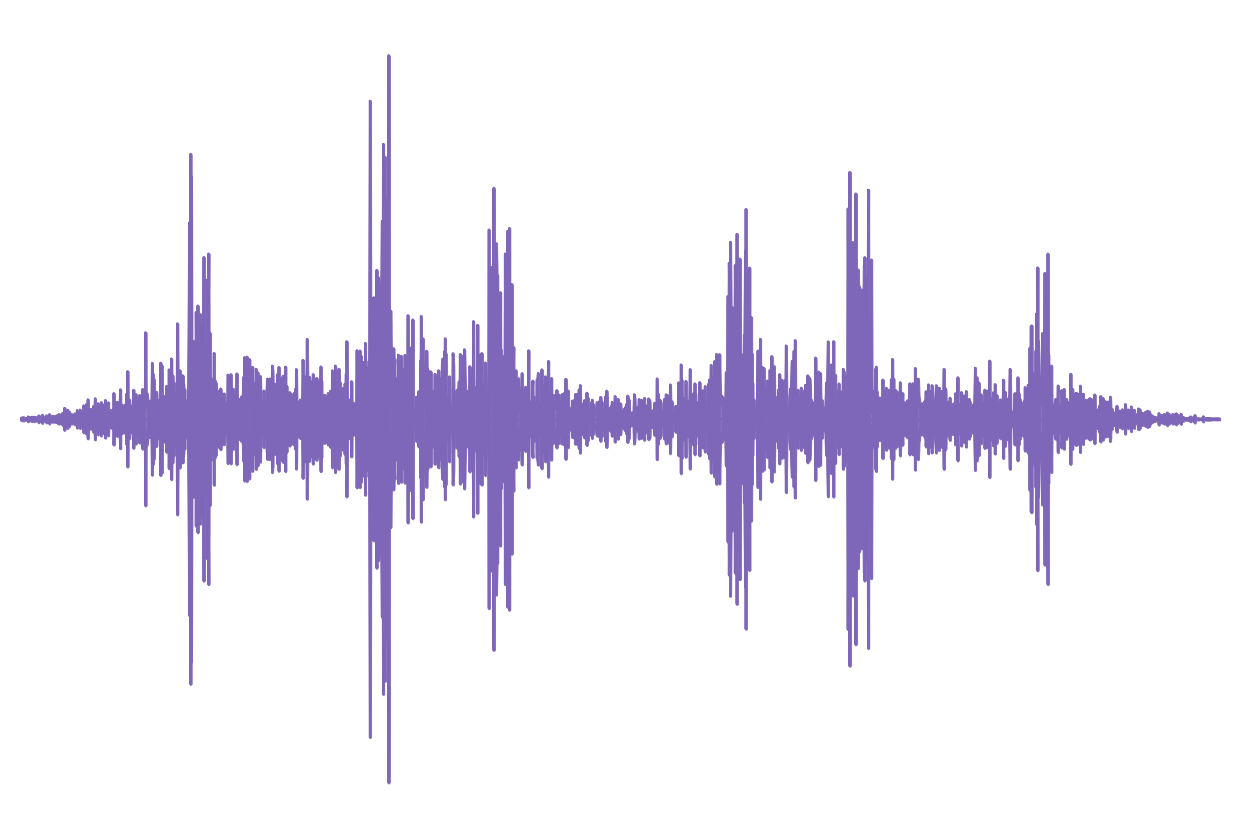

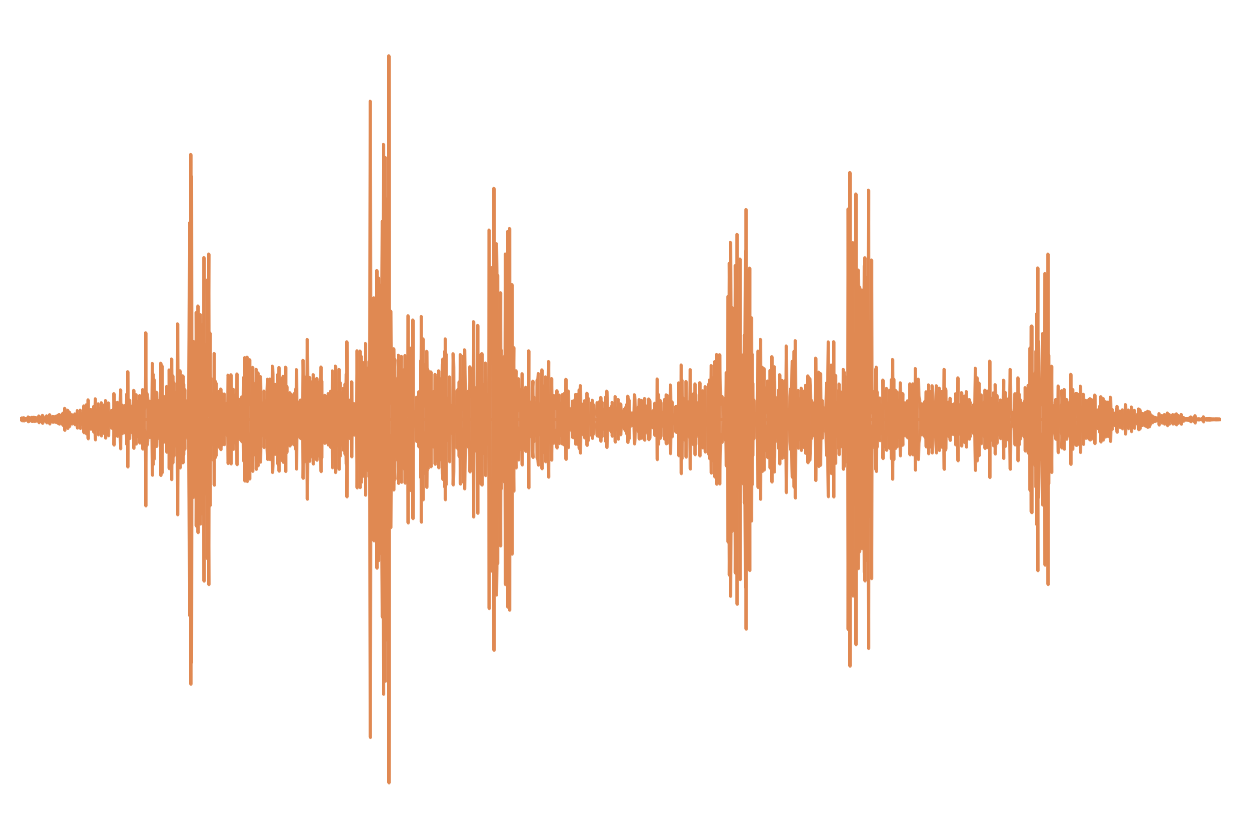

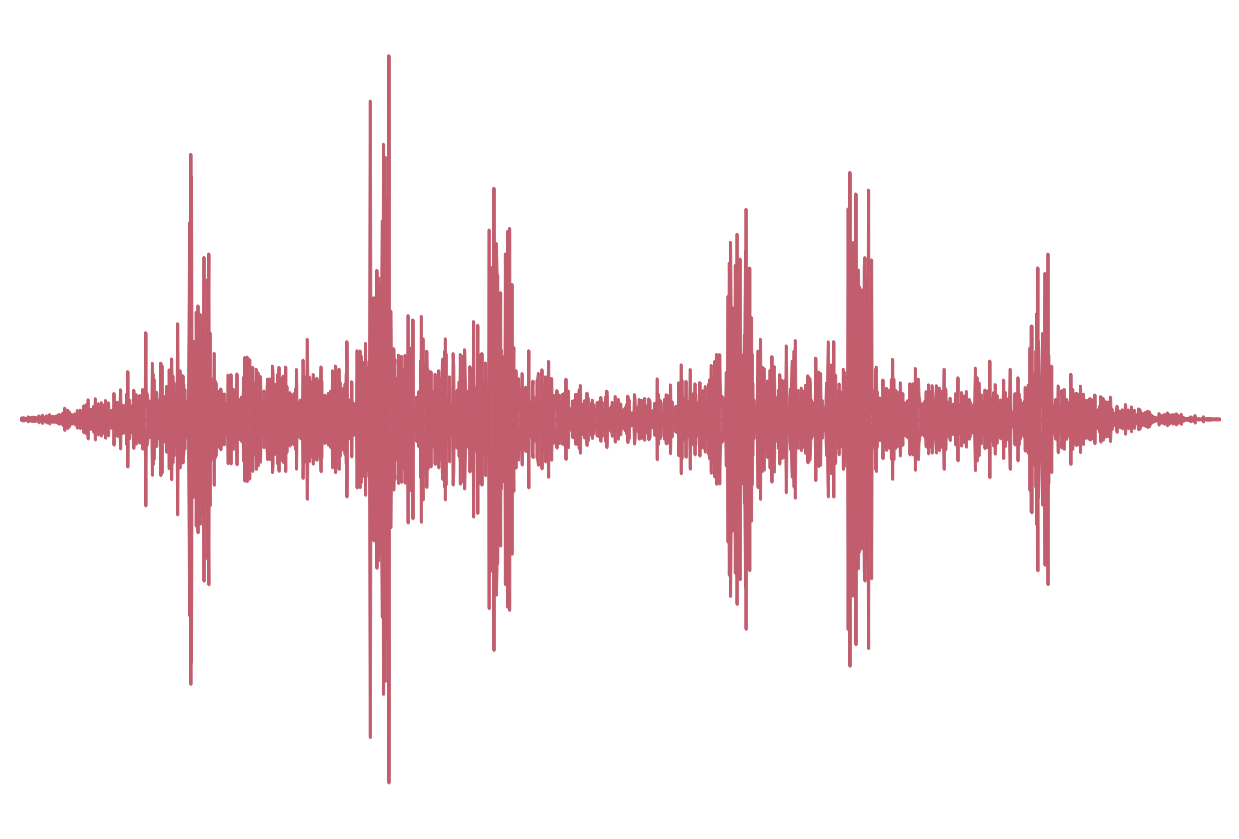

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成波形
np.random.seed(42)
n_samples = 2000
t = np.linspace(0, 10, n_samples)

envelope = np.zeros_like(t)
peak_positions = [1.5, 3, 4, 6, 7, 8.5]
peak_width = 0.8

for pos in peak_positions:
    envelope += np.exp(-((t - pos) / peak_width) ** 2)

envelope *= np.exp(-(t / 12) ** 2)

noise = np.random.normal(0, 0.3, n_samples)

for pos in peak_positions:
    idx = np.argmin(np.abs(t - pos))
    noise[idx - 20:idx + 20] *= 4

signal = noise * envelope

# 2. 五种波形颜色
wave_colors = [
    (83 / 255, 116 / 255, 186 / 255),   # 蓝色
    (74 / 255, 160 / 255, 170 / 255),   # 青绿色
    (126 / 255, 102 / 255, 184 / 255),  # 紫色
    (224 / 255, 137 / 255, 82 / 255),   # 橙色
    (194 / 255, 93 / 255, 110 / 255)    # 红色
]

bg_color = (1, 1, 1)

# 3. 分别绘制五张波形图
for i, wave_color in enumerate(wave_colors, start=1):
    plt.figure(
        figsize=(6, 4),
        dpi=200,
        facecolor=bg_color
    )

    plt.axhline(
        0,
        color=wave_color,
        linewidth=1
    )

    plt.fill_between(
        t,
        signal,
        0,
        color=wave_color,
        alpha=0.9
    )

    plt.fill_between(
        t,
        -signal,
        0,
        color=wave_color,
        alpha=0.9
    )

    plt.plot(
        t,
        signal,
        color=wave_color,
        linewidth=0.8
    )

    plt.plot(
        t,
        -signal,
        color=wave_color,
        linewidth=0.8
    )

    plt.axis("off")
    plt.xlim(t.min(), t.max())

    max_amplitude = np.max(np.abs(signal))
    plt.ylim(
        -max_amplitude * 1.1,
        max_amplitude * 1.1
    )

    plt.tight_layout(pad=0)

    # 保存为高清透明边界图片
    plt.savefig(
        f"waveform_color_{i}.png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0,
        facecolor=bg_color
    )

    plt.show()
    plt.close()